# Logistic Regression as a Single Neuron Model

## Imports

In [1]:
import numpy as np
import h5py
import requests
import os
import matplotlib.pyplot as plt

## Helper Functions

In [2]:
def download_file(url, local_filename):
    """
    Downloads a file from a URL and saves it locally.
    """
    if not os.path.exists(local_filename):
        print(f"Downloading {local_filename}...")
        response = requests.get(url)
        if response.status_code == 200:
            with open(local_filename, 'wb') as f:
                f.write(response.content)
            print(f"File downloaded: {local_filename}")
        else:
            raise Exception(f"Failed to download file from {url}. Status code: {response.status_code}")
    else:
        print(f"File already exists: {local_filename}")

def load_dataset():
    # URLs of the .h5 files
    train_url = 'https://github.com/PyDataGBC/PyML2025/raw/refs/heads/main/LabWeek2/dataset/train_catvnoncat.h5'
    test_url = 'https://github.com/PyDataGBC/PyML2025/raw/refs/heads/main/LabWeek2/dataset/test_catvnoncat.h5'

    # Local file paths
    train_file = 'train_catvnoncat.h5'
    test_file = 'test_catvnoncat.h5'

    # Download the files if not already present
    download_file(train_url, train_file)
    download_file(test_url, test_file)

    # Open the files using h5py
    train_dataset = h5py.File(train_file, "r")
    train_set_x_orig = np.array(train_dataset["train_set_x"][:])  # Train set features
    train_set_y_orig = np.array(train_dataset["train_set_y"][:])  # Train set labels

    test_dataset = h5py.File(test_file, "r")
    test_set_x_orig = np.array(test_dataset["test_set_x"][:])  # Test set features
    test_set_y_orig = np.array(test_dataset["test_set_y"][:])  # Test set labels

    classes = np.array(test_dataset["list_classes"][:])  # List of classes

    # Reshape labels
    train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
    test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))

    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes

## Importing Dataset

In [3]:
train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes = load_dataset()

File downloaded: train_catvnoncat.h5
File downloaded: test_catvnoncat.h5


## Data Visualization

label:  [1]


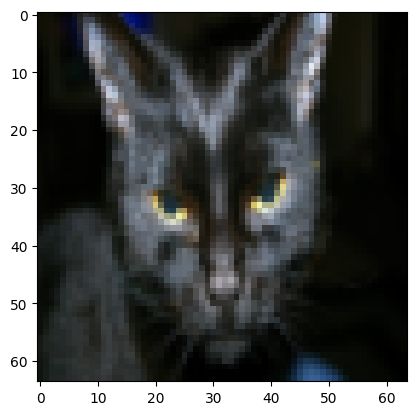

In [4]:
# Example of a picture
index = 25
plt.imshow(train_set_x_orig[index])
print("label: ", train_set_y[:, index])

### **Exercise 1:** Take a look at five different images in test set. Try to see both cat and non-cat samples.

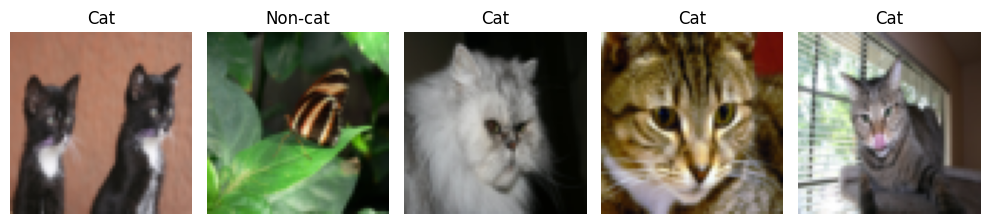

In [5]:
#your code here
# Define indices of five different images
indices = [0, 5, 10, 15, 20]  # Adjust as needed to cover a mix of cat and non-cat images

# Plot the images
plt.figure(figsize=(10, 10))
for i, index in enumerate(indices):
    plt.subplot(1, 5, i + 1)
    plt.imshow(test_set_x_orig[index])
    label = "Cat" if test_set_y[0, index] == 1 else "Non-cat"
    plt.title(label)
    plt.axis("off")
plt.tight_layout()
plt.show()


### **Exercise 2:** What percentage of the pictures contain cats?

In [28]:
#your code
cat_image = 0
not_cat = 0
for i in range (train_set_x_orig.shape[0]):
  if 1 in train_set_y[:, i]:
    cat_image += 1
  else:
      not_cat += 1
print(f"Number of cat images: {cat_image}")
print(f"Number of non-cat images:{not_cat}")

perc_cat = cat_image / (cat_image * not_cat)
print(f"Percentage of cat images: {perc_cat}")

Number of cat images: 72
Number of non-cat images:137
Percentage of cat images: 0.0072992700729927005


## Data Preprocessing

### Numerical Representation of Images

![preprocessing](https://raw.githubusercontent.com/PyDataGBC/PyML2025/refs/heads/main/LabWeek2/assets/imvectorkiank.png)

### Simple Numerical Example

![](https://raw.githubusercontent.com/PyDataGBC/PyML2025/refs/heads/main/LabWeek2/assets/imtovec_example.webp)

In [7]:
airplane_image = np.array([[[255, 123, 135],[44, 12, 15],[56, 87, 90]],[[255, 133, 175],[24, 123, 169],[98, 66, 77]],[[66, 54, 88 ],[55, 98, 54],[87, 142, 89]]])
print(airplane_image.shape)
print(airplane_image)

(3, 3, 3)
[[[255 123 135]
  [ 44  12  15]
  [ 56  87  90]]

 [[255 133 175]
  [ 24 123 169]
  [ 98  66  77]]

 [[ 66  54  88]
  [ 55  98  54]
  [ 87 142  89]]]


In [8]:
airplane_flatten = airplane_image.flatten()
print(airplane_flatten.shape)
print(airplane_flatten)

(27,)
[255 123 135  44  12  15  56  87  90 255 133 175  24 123 169  98  66  77
  66  54  88  55  98  54  87 142  89]


### **Exercise 3:** Check the shape of the train and test datasets along with their labels. Try to interpret the numbers in the shapes.

**Notes:**
- The images are 64x64 `pixels`.
- There are 3 RGB `channels`.
- The train set contains 209 `batches` of images, and the test set contains 50 `batches` of images.

In [9]:
#your code here
# Check the shape of the train and test datasets
print("Training set feature shape:", train_set_x_orig.shape)
print("Training set label shape:", train_set_y.shape)

print("Test set feature shape:", test_set_x_orig.shape)
print("Test set label shape:", test_set_y.shape)

# Interpret the numbers in the shapes
print("\nInterpretation:")
print(f"The training set contains {train_set_x_orig.shape[0]} images, each of size {train_set_x_orig.shape[1]}x{train_set_x_orig.shape[2]} pixels with {train_set_x_orig.shape[3]} RGB channels.")
print(f"The test set contains {test_set_x_orig.shape[0]} images, each of size {test_set_x_orig.shape[1]}x{test_set_x_orig.shape[2]} pixels with {test_set_x_orig.shape[3]} RGB channels.")

print(f"The training set has {train_set_y.shape[1]} labels corresponding to the {train_set_x_orig.shape[0]} images.")
print(f"The test set has {test_set_y.shape[1]} labels corresponding to the {test_set_x_orig.shape[0]} images.")


Training set feature shape: (209, 64, 64, 3)
Training set label shape: (1, 209)
Test set feature shape: (50, 64, 64, 3)
Test set label shape: (1, 50)

Interpretation:
The training set contains 209 images, each of size 64x64 pixels with 3 RGB channels.
The test set contains 50 images, each of size 64x64 pixels with 3 RGB channels.
The training set has 209 labels corresponding to the 209 images.
The test set has 50 labels corresponding to the 50 images.


### Flattening the Train and Test Datasets

In [10]:
train_flat = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1)
print(train_flat.shape)

test_flat = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1)
print(test_flat.shape)

train_label = train_set_y[0]
print(train_label.shape)

test_label = test_set_y[0]
print(test_label.shape)



(209, 12288)
(50, 12288)
(209,)
(50,)


### Exercise 4: Why the dimension of flattened image is 12288?

In [11]:
image_shape = (64, 64, 3)  # Height, Width, Channels
flattened_dimension = image_shape[0] * image_shape[1] * image_shape[2]
print(f"Flattened dimension: {flattened_dimension}")

Flattened dimension: 12288


## Implementing Logistic Regression

![](https://raw.githubusercontent.com/PyDataGBC/PyML2025/refs/heads/main/LabWeek2/assets/LogReg_kiank.png)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


### **Exercise 5:** Train a `LogisticRegression` classifier to run a binary classification on the flattened cat pictures.

Test set accuracy: 70.00%


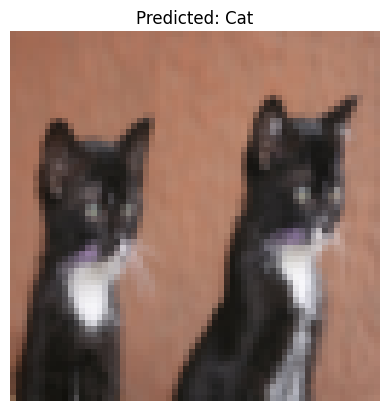

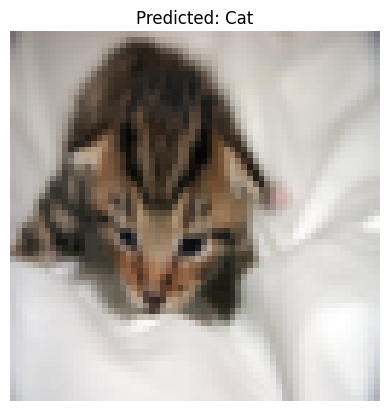

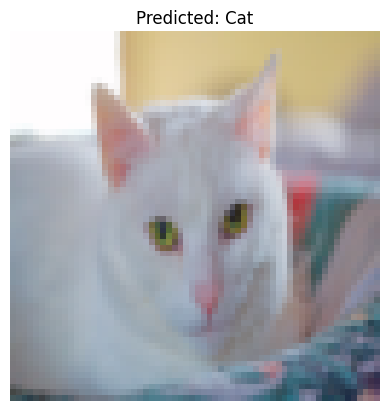

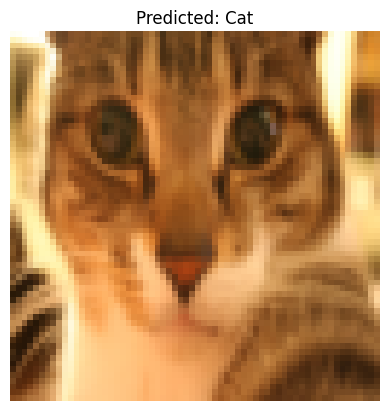

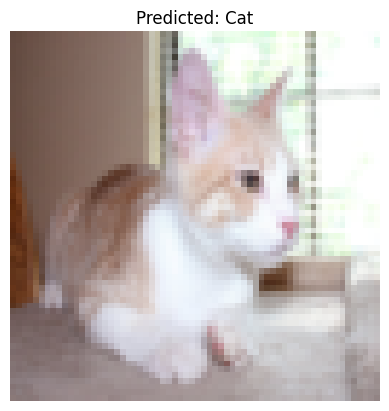

In [13]:
#your code here
# Normalize the flattened data to range [0, 1]
train_flat = train_flat / 255.0
test_flat = test_flat / 255.0

# Train the Logistic Regression model
model = LogisticRegression(max_iter=2000)
model.fit(train_flat, train_label)

# Predict on the test set
test_predictions = model.predict(test_flat)

# Calculate and print the accuracy
accuracy = accuracy_score(test_label, test_predictions)
print(f"Test set accuracy: {accuracy * 100:.2f}%")

# Example: Display predictions for some test images
import matplotlib.pyplot as plt

for i in range(5):  # Display first 5 test images
    plt.imshow(test_set_x_orig[i])  # Show the original image
    plt.title(f"Predicted: {'Cat' if test_predictions[i] == 1 else 'Non-cat'}")
    plt.axis("off")
    plt.show()


### **Exercise 6:** Evaluate your model manually

1. Choose a random index of an image.
2. Display the image.
3. Print the original label.
4. Print the predicted label.
5. Repeat this process multiple times to identify which pictures are more challenging for the model.

### **Exercise 7:** Report the overall accuracy of your classifier.

In [16]:
#your code here
from sklearn.metrics import accuracy_score

#Calculate the overall accuracy
overall_accuracy = accuracy_score(test_label, test_predictions)

#Print the accuracy in percentage
print(f"Overall accuracy of the classifier: {overall_accuracy * 100:.2F}%")


Overall accuracy of the classifier: 70.00%


## MNIST dataset (Optional)

In [17]:
#import mnist dataset
from keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [18]:
x_train.shape

(60000, 28, 28)

Label:  0
Image Shape:  (28, 28)


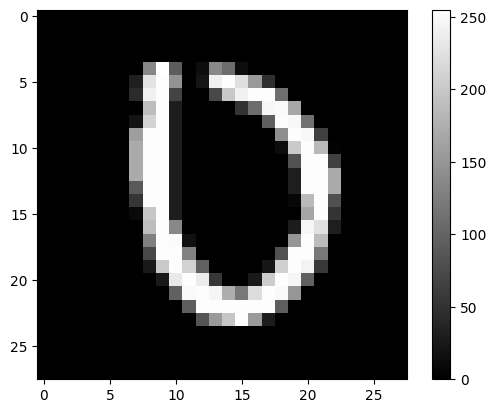

In [22]:
#Note: Run this cell multiple times
index = np.random.randint(0, x_train.shape[0])
print("Label: ", y_train[index])
print("Image Shape: ", x_train[index].shape)
plt.imshow(x_train[index], cmap='gray')
plt.colorbar()

### **Excercise 8:** What is the difference between a black-and-white image and a color image in terms of numerical representation?

your answer here: A black-and-white image (grayscale) is represented as a 2D matrix where each pixel has a single intensity value ranging from 0 (black) to 255 (white), while a color image (RGB) is represented as a 3D matrix with three channeles-Red, Green, and Blue-where each pixel has three intensity values, one for each channel, also ranging from 0 to 255.


### **Exercise 9:** Select one data sample and flatten it. What is the size of the flattened image and why?

In [23]:
## your code here
# Select one data sample (e.g., the first sample in the training set)
sample_image = x_train[0]

# Print the original shape of the image
print("Original shape of the sample image:", sample_image.shape)

# Flatten the image
flattened_image = sample_image.flatten()

# Print the shape of the flattened image
print("Shape of the flattened image:", flattened_image.shape)

# Explanation for the size
print("Explanation: The original image has a shape of 28x28 pixels, which equals 784 when flattened.")


Original shape of the sample image: (28, 28)
Shape of the flattened image: (784,)
Explanation: The original image has a shape of 28x28 pixels, which equals 784 when flattened.


### **Excercise 10:** Flatten the Entire Train and Test Datasets

In [24]:
##your code here
# Flatten the entire training dataset
x_train_flattened = x_train.reshape(x_train.shape[0], -1)
print("Shape of flattened training dataset:", x_train_flattened.shape)

# Flatten the entire test dataset
x_test_flattened = x_test.reshape(x_test.shape[0], -1)
print("Shape of flattened test dataset:", x_test_flattened.shape)

# Explanation for the shape
print("Explanation: Each image in the dataset has a shape of 28x28 pixels, which equals 784 when flattened. The entire training dataset has 60,000 samples, so its flattened shape is (60000, 784). Similarly, the test dataset has 10,000 samples, so its shape is (10000, 784).")


Shape of flattened training dataset: (60000, 784)
Shape of flattened test dataset: (10000, 784)
Explanation: Each image in the dataset has a shape of 28x28 pixels, which equals 784 when flattened. The entire training dataset has 60,000 samples, so its flattened shape is (60000, 784). Similarly, the test dataset has 10,000 samples, so its shape is (10000, 784).


**Some food for thought:** What would the architecture of my model be if I used more than one neuron to predict the label?